In [13]:
import requests
import pandas as pd
import numpy as np
import json
import io
import os
import random
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

# settings
random.seed(42)
RESULTS_DIR = '/rds/general/user/ys5320/home/scrna_project/results/'
DOWNLOAD_DIR = '/rds/general/user/ys5320/home/scrna_project/data/tcga_brca_counts/'
os.makedirs(DOWNLOAD_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

In [14]:
# download TCGA-BRCA clinical data with PAM50 subtypes
url = "https://tcga-xena-hub.s3.us-east-1.amazonaws.com/download/TCGA.BRCA.sampleMap%2FBRCA_clinicalMatrix"
response = requests.get(url)
xena_clinical = pd.read_csv(io.StringIO(response.text), sep='\t', index_col=0)

print(f"Clinical data shape: {xena_clinical.shape}")
print(f"\nPAM50 subtype counts:")
print(xena_clinical['PAM50Call_RNAseq'].value_counts())

Clinical data shape: (1247, 193)

PAM50 subtype counts:
PAM50Call_RNAseq
LumA      434
LumB      194
Basal     142
Normal    119
Her2       67
Name: count, dtype: int64


In [15]:
# select Basal (TNBC-like) and LumA (ER+-like) samples
basal = xena_clinical[xena_clinical['PAM50Call_RNAseq'] == 'Basal'].index.tolist()
luma = xena_clinical[xena_clinical['PAM50Call_RNAseq'] == 'LumA'].index.tolist()

# take 50 samples from each group
basal_subset = random.sample(basal, 50)
luma_subset = random.sample(luma, 50)
selected_samples = basal_subset + luma_subset

print(f"Basal samples: {len(basal_subset)}")
print(f"LumA samples: {len(luma_subset)}")
print(f"Total selected: {len(selected_samples)}")

Basal samples: 50
LumA samples: 50
Total selected: 100


In [16]:
# query GDC API for STAR counts files
files_endpt = "https://api.gdc.cancer.gov/files"

filters = {
    "op": "and",
    "content": [
        {"op": "=", "content": {"field": "cases.project.project_id", "value": "TCGA-BRCA"}},
        {"op": "=", "content": {"field": "data_category", "value": "Transcriptome Profiling"}},
        {"op": "=", "content": {"field": "data_type", "value": "Gene Expression Quantification"}},
        {"op": "=", "content": {"field": "analysis.workflow_type", "value": "STAR - Counts"}}
    ]
}

params = {
    "filters": json.dumps(filters),
    "fields": "file_id,file_name,cases.submitter_id,cases.samples.submitter_id,cases.samples.sample_type",
    "format": "JSON",
    "size": "1231"
}

response = requests.get(files_endpt, params=params)
files_data = response.json()
print(f"Total files available: {files_data['data']['pagination']['total']}")

# match sample barcodes to file IDs
file_map = {}
for hit in files_data['data']['hits']:
    for case in hit.get('cases', []):
        for sample in case.get('samples', []):
            sample_id = sample.get('submitter_id', '')
            sample_type = sample.get('sample_type', '')
            if sample_type == 'Primary Tumor':
                sample_short = sample_id[:15]
                for sel in selected_samples:
                    if sel[:15] == sample_short:
                        file_map[sel] = {
                            'file_id': hit['file_id'],
                            'file_name': hit['file_name']
                        }

print(f"Files matched: {len(file_map)}")

Total files available: 1231
Files matched: 94


In [17]:
data_endpt = "https://api.gdc.cancer.gov/data"

print(f"Downloading {len(file_map)} files...")
for i, (sample_id, file_info) in enumerate(file_map.items()):
    file_path = os.path.join(DOWNLOAD_DIR, f"{sample_id}.tsv")
    
    if os.path.exists(file_path):
        continue
    
    response = requests.get(f"{data_endpt}/{file_info['file_id']}", stream=True)
    with open(file_path, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    
    if (i+1) % 10 == 0:
        print(f"Downloaded {i+1}/{len(file_map)}")

print(f"Done! Files in directory: {len(os.listdir(DOWNLOAD_DIR))}")

Done! Files in directory: 94


In [18]:
counts_dict = {}
metadata_list = []

basal_set = set(basal_subset)
luma_set = set(luma_subset)

for sample_file in os.listdir(DOWNLOAD_DIR):
    sample_id = sample_file.replace('.tsv', '')
    file_path = os.path.join(DOWNLOAD_DIR, sample_file)
    
    df = pd.read_csv(file_path, sep='\t', comment='#')
    df = df.dropna(subset=['gene_name'])
    df = df.set_index('gene_name')['unstranded']
    counts_dict[sample_id] = df
    
    if sample_id in basal_set:
        subtype = 'Basal'
    elif sample_id in luma_set:
        subtype = 'LumA'
    else:
        subtype = 'Unknown'
    
    metadata_list.append({'sample_id': sample_id, 'subtype': subtype})

counts_df = pd.DataFrame(counts_dict)
metadata_df = pd.DataFrame(metadata_list).set_index('sample_id')

print(f"Count matrix: {counts_df.shape}")
print(f"Subtypes: {metadata_df['subtype'].value_counts().to_dict()}")
print(f"\nSample values (should be integers):")
print(counts_df.iloc[:3, :3])

Count matrix: (60660, 94)
Subtypes: {'Basal': 48, 'LumA': 46}

Sample values (should be integers):
           TCGA-BH-A1FH-01  TCGA-HN-A2NL-01  TCGA-E2-A150-01
gene_name                                                   
TSPAN6                4509             5598             4070
TNMD                    68                1                2
DPM1                  2147             3083             2848


In [20]:
# fix duplicate gene names by making them unique
counts_filtered_unique = counts_filtered.copy()
counts_filtered_unique.columns = pd.io.common.dedup_names(
    counts_filtered_unique.columns.tolist(), 
    is_potential_multiindex=False
)

# verify no duplicates
print(f"Duplicate genes before: {counts_filtered.columns.duplicated().sum()}")
print(f"Duplicate genes after: {counts_filtered_unique.columns.duplicated().sum()}")

# rerun DESeq2 with deduplicated gene names
dds = DeseqDataSet(
    counts=counts_filtered_unique,
    metadata=meta_filtered,
    design_factors='subtype',
    ref_level=['subtype', 'LumA']
)

print("Running DESeq2...")
dds.deseq2()
print("DESeq2 done!")

Duplicate genes before: 986
Duplicate genes after: 0
Running DESeq2...
Using None as control genes, passed at DeseqDataSet initialization


/rds/general/user/ys5320/ephemeral/ipykernel_3835413/1958703814.py:13: DeprecationWarning: ref_level is deprecated and no longer has any effect. It will beremoved in a future release.
  dds = DeseqDataSet(
/rds/general/user/ys5320/ephemeral/ipykernel_3835413/1958703814.py:13: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.13 seconds.

Fitting dispersions...
... done in 7.00 seconds.

Fitting dispersion trend curve...
... done in 0.95 seconds.

Fitting MAP dispersions...
... done in 8.04 seconds.

Fitting LFCs...
... done in 5.64 seconds.

Calculating cook's distance...
... done in 0.31 seconds.

Replacing 9371 outlier genes.

Fitting dispersions...
... done in 1.28 seconds.

Fitting MAP dispersions...
... done in 1.31 seconds.

Fitting LFCs...
... done in 1.15 seconds.



DESeq2 done!


In [21]:
# extract DEG results
stat_res = DeseqStats(dds, contrast=['subtype', 'Basal', 'LumA'])
stat_res.summary()

# get results dataframe
results_df = stat_res.results_df
print(f"Total genes tested: {len(results_df)}")
print(f"\nFirst few results:")
print(results_df.head())

# filter significant DEGs
sig_deg = results_df[
    (results_df['padj'] < 0.05) & 
    (abs(results_df['log2FoldChange']) > 1)
].copy()

print(f"\nSignificant DEGs (padj<0.05, |log2FC|>1): {len(sig_deg)}")
print(f"\nTop 10 upregulated in Basal:")
print(sig_deg.nlargest(10, 'log2FoldChange')[['log2FoldChange', 'padj']])
print(f"\nTop 10 downregulated in Basal:")
print(sig_deg.nsmallest(10, 'log2FoldChange')[['log2FoldChange', 'padj']])

# save
results_df.to_csv(RESULTS_DIR + 'deseq2_basal_vs_luma.csv')
sig_deg.to_csv(RESULTS_DIR + 'deseq2_sig_basal_vs_luma.csv')
print("Saved!")

Running Wald tests...
... done in 2.42 seconds.



Log2 fold change & Wald test p-value: subtype Basal vs LumA
               baseMean  log2FoldChange     lfcSE      stat        pvalue  \
TSPAN6      3234.322115        0.576836  0.181482  3.178479  1.480500e-03   
TNMD          30.397663       -0.965568  0.453480 -2.129242  3.323428e-02   
DPM1        2496.542436        0.514212  0.098874  5.200683  1.985577e-07   
SCYL3       1634.377494       -0.506655  0.112610 -4.499207  6.820748e-06   
C1orf112     958.322486        1.116889  0.139658  7.997320  1.271564e-15   
...                 ...             ...       ...       ...           ...   
AC078856.1     0.397537       -0.262649  1.110339 -0.236549  8.130069e-01   
AC008763.4     0.071965        0.106907  2.284259  0.046802  9.626714e-01   
AL592295.6   428.440168        0.185724  0.134988  1.375861  1.688647e-01   
AL391628.1     7.909436        0.117536  0.223907  0.524930  5.996315e-01   
AP006621.6    28.195732        0.366335  0.213667  1.714511  8.643495e-02   

               

In [22]:
import gseapy as gp

# prepare ranked gene list for GSEA
# use stat column (Wald statistic) for ranking — better than log2FC for GSEA
results_clean = results_df.dropna(subset=['stat'])
ranked_genes = results_clean['stat'].sort_values(ascending=False)

print(f"Genes for GSEA: {len(ranked_genes)}")
print(f"Top ranked: {ranked_genes.head()}")
print(f"Bottom ranked: {ranked_genes.tail()}")

# run GSEA
gsea_results = gp.prerank(
    rnk=ranked_genes,
    gene_sets='MSigDB_Hallmark_2020',
    threads=4,
    min_size=15,
    max_size=500,
    permutation_num=100,
    outdir=RESULTS_DIR + 'gsea_bulk_basal_vs_luma',
    seed=42,
    verbose=False
)

gsea_df = gsea_results.res2d
print(gsea_df[['Term', 'NES', 'NOM p-val', 'FDR q-val']].head(20))
gsea_df.to_csv(RESULTS_DIR + 'gsea_bulk_basal_vs_luma.csv', index=False)
print("Saved!")

2026-05-07 12:44:10,925 [WARNING] Duplicated values found in preranked stats: 10.80% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Genes for GSEA: 56163
Top ranked: FOXCUT     24.429821
HORMAD1    18.651654
FOXC1      18.408009
HPDL       18.380164
A2ML1      18.297547
Name: stat, dtype: float64
Bottom ranked: SCUBE2      -22.565624
CT62        -23.543443
FSIP1       -23.560108
LINC00504   -23.582027
TBC1D9      -24.962288
Name: stat, dtype: float64
                                 Term       NES  NOM p-val  FDR q-val
0                         E2F Targets   2.82574       0.01   0.010000
1             Estrogen Response Early -2.691336       0.01   0.010000
2                     G2-M Checkpoint  2.572666       0.01   0.010000
3                      Myc Targets V1  2.570265       0.01   0.010000
4                      Myc Targets V2  2.400977       0.01   0.010000
5              Estrogen Response Late -2.030941       0.01   0.010000
6                    mTORC1 Signaling  1.983411       0.01   0.010000
7                 Allograft Rejection  1.856485       0.01   0.010000
8                     Mitotic Spindle  1.818288

Volcano plot saved!

Summary:
Upregulated in Basal: 7497
Upregulated in LumA: 3704


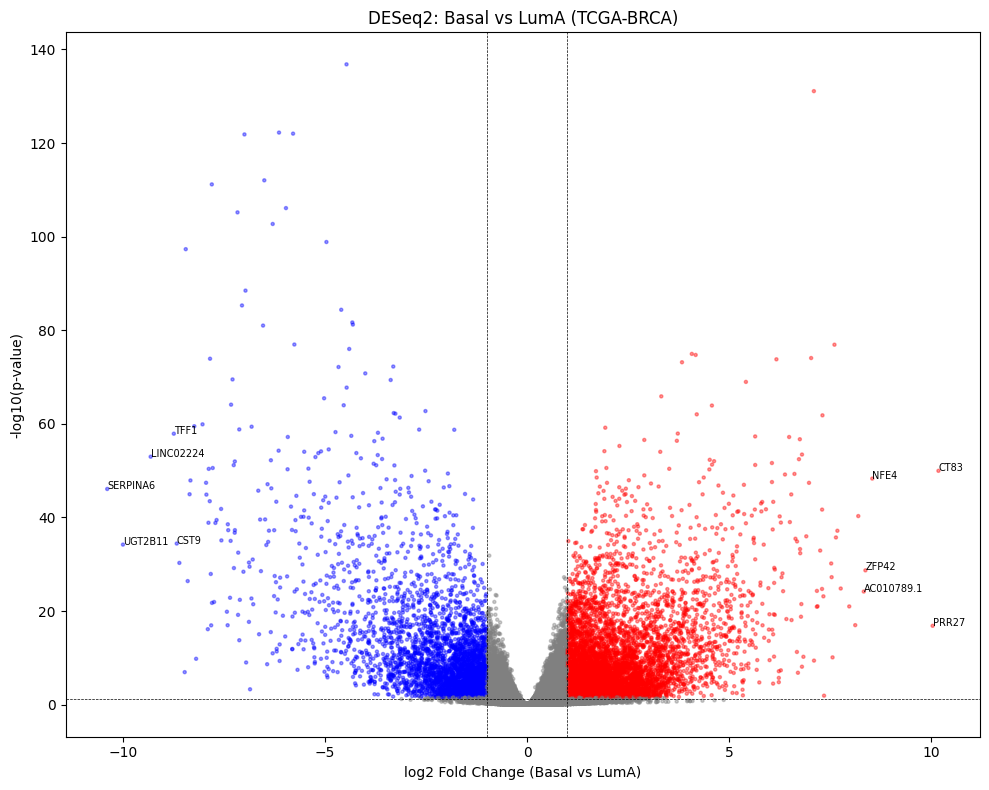

In [23]:
import matplotlib.pyplot as plt
import matplotlib

# volcano plot
fig, ax = plt.subplots(figsize=(10, 8))

# colour points
results_plot = results_df.copy()
results_plot['colour'] = 'grey'
results_plot.loc[
    (results_plot['padj'] < 0.05) & (results_plot['log2FoldChange'] > 1), 
    'colour'] = 'red'
results_plot.loc[
    (results_plot['padj'] < 0.05) & (results_plot['log2FoldChange'] < -1), 
    'colour'] = 'blue'

ax.scatter(results_plot['log2FoldChange'], 
           -np.log10(results_plot['pvalue']),
           c=results_plot['colour'], alpha=0.4, s=5)

ax.axvline(x=1, color='black', linestyle='--', linewidth=0.5)
ax.axvline(x=-1, color='black', linestyle='--', linewidth=0.5)
ax.axhline(y=-np.log10(0.05), color='black', linestyle='--', linewidth=0.5)

ax.set_xlabel('log2 Fold Change (Basal vs LumA)')
ax.set_ylabel('-log10(p-value)')
ax.set_title('DESeq2: Basal vs LumA (TCGA-BRCA)')

# label top genes
top_genes = sig_deg.nlargest(5, 'log2FoldChange').index.tolist() + \
            sig_deg.nsmallest(5, 'log2FoldChange').index.tolist()
for gene in top_genes:
    if gene in results_plot.index:
        x = results_plot.loc[gene, 'log2FoldChange']
        y = -np.log10(results_plot.loc[gene, 'pvalue'])
        ax.annotate(gene, (x, y), fontsize=7)

plt.tight_layout()
plt.savefig('/rds/general/user/ys5320/home/scrna_project/figures/volcano_bulk_basal_vs_luma.png', 
            dpi=150)
print("Volcano plot saved!")

# print summary
up_basal = len(sig_deg[sig_deg['log2FoldChange'] > 1])
up_luma = len(sig_deg[sig_deg['log2FoldChange'] < -1])
print(f"\nSummary:")
print(f"Upregulated in Basal: {up_basal}")
print(f"Upregulated in LumA: {up_luma}")